# EDA Hands-On Lab — Ames Housing Dataset

**Master's in Data Science — LUISS Guido Carli**

| | |
|---|---|
| **Format** | Hands-on practical lab (~90 min) |
| **Dataset** | Ames Housing — 1,460 houses, 81 features, target: SalePrice |
| **Slides** | EDA_Lecture.pptx — use as reference throughout |
| **Goal** | Execute a complete, systematic EDA workflow from raw data to modeling-ready features |

### Structure
We follow the **EDA pipeline** step by step:

| Step | What | Time | Slides |
|------|------|------|--------|
| 0 | Setup & Load | 3 min | 2 |
| 1 | First Contact — shape, types, sanity | 7 min | 4-6 |
| 2 | Data Types — numerical vs categorical | 7 min | 8-9 |
| 3 | Summary Statistics — center, spread, shape | 10 min | 11-16 |
| 4 | Univariate Analysis — distributions one at a time | 12 min | 18-22 |
| 5 | Bivariate Analysis — relationships between pairs | 15 min | 24-29 |
| 6 | Multivariate — PCA, pair plots | 8 min | 31-33 |
| 7 | Missing Data — patterns & imputation | 10 min | 36-38 |
| 8 | Outliers — detection & strategy | 8 min | 40-42 |
| 9 | Transformations — log, scaling, encoding | 8 min | 44-46 |
| 10 | Wrap-up — checklist & Anscombe | 2 min | 48-53 |

---
## Step 0 — Setup & Data Loading `[Slide 2]` 3 min

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05, palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

# Color palette
NAVY, STEEL, CORAL, GREEN = '#1A3764', '#4682B4', '#E8735A', '#27AE60'

print(' Setup complete')

 Setup complete


In [2]:
# Load Ames Housing dataset
from sklearn.datasets import fetch_openml
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 1,460 rows × 81 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,...,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,...,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,...,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,...,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


---
## Step 1 — First Contact with the Data `[Slides 4-6]` 7 min

> *"Let the data speak — don't impose assumptions prematurely."* — Tukey

Before any analysis: **understand what you have**. Shape, types, basic sanity checks.

In [3]:
# 1a. Basic shape & memory 
print(f'Rows: {df.shape[0]:>6,}')
print(f'Columns: {df.shape[1]:>6}')
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'\nColumn names (first 20):')
print(list(df.columns[:20]))

Rows:  1,460
Columns:     81
Memory: 4.1 MB

Column names (first 20):
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt']


In [4]:
# 1b. Check for duplicates 
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup}')

# Check Id column — is it unique?
if 'Id' in df.columns:
 print(f'Unique Id values: {df["Id"].nunique()} (should be {len(df)})')

Duplicate rows: 0
Unique Id values: 1460 (should be 1460)


In [5]:
# 1c. Target variable: first look 
target = 'SalePrice'
print(f'Target: {target}')
print(f' Min: ${df[target].min():>10,.0f}')
print(f' Max: ${df[target].max():>10,.0f}')
print(f' Mean: ${df[target].mean():>10,.0f}')
print(f' Median: ${df[target].median():>10,.0f}')
print(f' Missing: {df[target].isnull().sum()}')

Target: SalePrice
 Min: $    34,900
 Max: $   755,000
 Mean: $   180,921
 Median: $   163,000
 Missing: 0


**Takeaway:** Mean > Median → right-skewed distribution (expensive homes pull the mean up). See `[Slide 11]` for why this matters.

---
## Step 2 — Data Types `[Slides 8-9]` 7 min

Choosing the right visualization and statistical test **depends entirely on data type**.

| | Continuous | Discrete | Nominal | Ordinal |
|---|---|---|---|---|
| Example | SalePrice | Bedrooms | BldgType | OverallQual |
| Plot | Histogram | Bar | Count plot | Ordered bar |
| Correlation | Pearson/Spearman | Spearman | Chi² | Spearman |

In [6]:
# 2a. Dtype distribution 
print('Pandas dtype counts:')
print(df.dtypes.value_counts())
print()

# Separate numerical and categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Numerical: {len(num_cols)} features')
print(f'Categorical: {len(cat_cols)} features')

# Remove Id from numerical if present (it's an identifier, not a feature)
if 'Id' in num_cols:
 num_cols.remove('Id')
 print(f'\n(Removed Id from numerical → {len(num_cols)} numerical features)')

Pandas dtype counts:
object     43
int64      35
float64     3
Name: count, dtype: int64

Numerical: 38 features
Categorical: 43 features

(Removed Id from numerical → 37 numerical features)


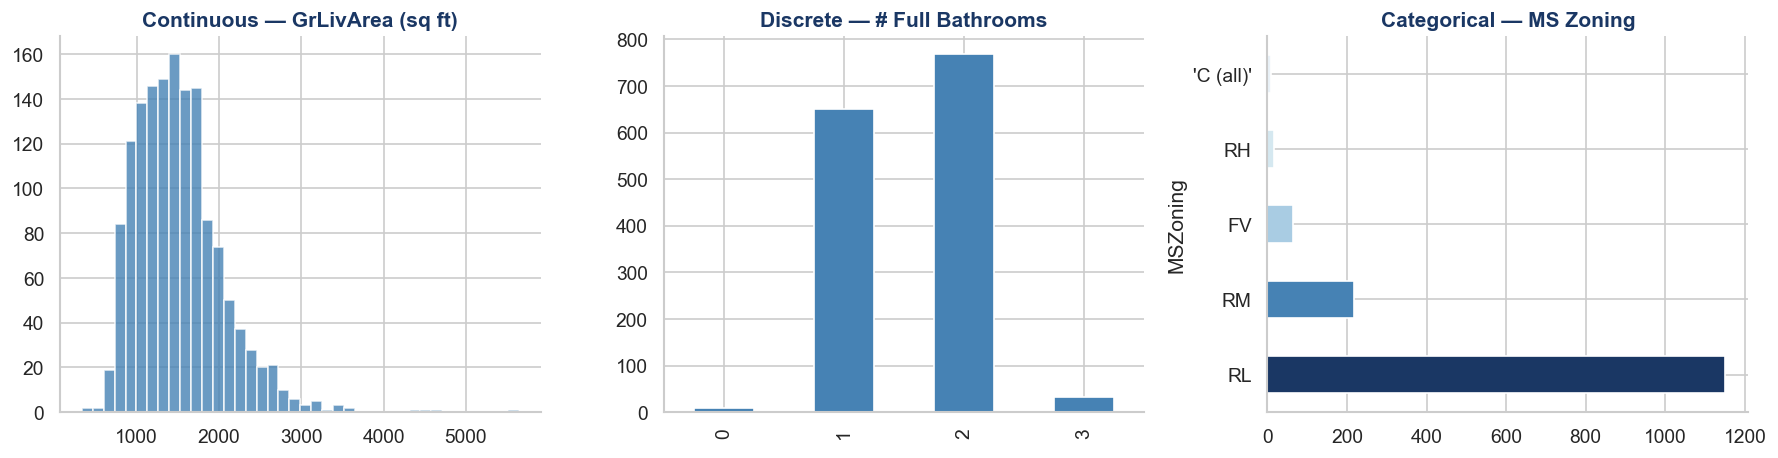

In [7]:
# 2b. Visual: one continuous, one discrete, one categorical
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Continuous
axes[0].hist(df['GrLivArea'], bins=40, color=STEEL, alpha=0.8, edgecolor='white')
axes[0].set_title('Continuous — GrLivArea (sq ft)', fontweight='bold', color=NAVY)

# Discrete
df['FullBath'].value_counts().sort_index().plot.bar(ax=axes[1], color=STEEL, edgecolor='white')
axes[1].set_title('Discrete — # Full Bathrooms', fontweight='bold', color=NAVY)
axes[1].set_xlabel('')

# Categorical
df['MSZoning'].value_counts().plot.barh(ax=axes[2], color=[NAVY, STEEL, '#A9CCE3', '#D5E8F0', '#EAF2F8'])
axes[2].set_title('Categorical — MS Zoning', fontweight='bold', color=NAVY)

for ax in axes.flatten():
 ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

 **Pandas dtype ≠ statistical type!** A zip code stored as `int64` is categorical. Always verify with domain knowledge. See `[Slide 9]`.

---
## Step 3 — Summary Statistics `[Slides 11-16]` 10 min

Three pillars: **center** (mean, median, mode), **spread** (std, IQR, CV), **shape** (skewness, kurtosis).

Mean: $   180,921 ← pulled by expensive homes
Median: $   163,000 ← robust to outliers
Mode: $   140,000

Mean > Median by $17,921 → right-skewed [Slide 11]


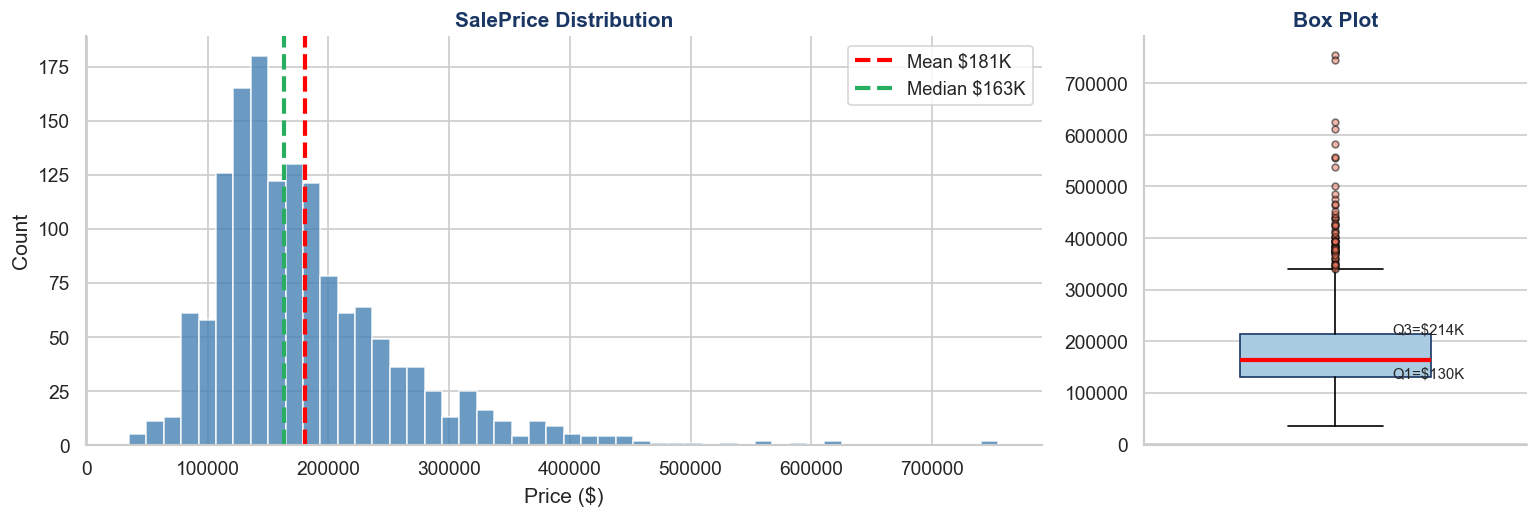

In [8]:
# 3a. Central tendency: SalePrice 
price = df['SalePrice']
mean_p = price.mean()
median_p = price.median()
mode_p = price.mode()[0]

print(f'Mean: ${mean_p:>10,.0f} ← pulled by expensive homes')
print(f'Median: ${median_p:>10,.0f} ← robust to outliers')
print(f'Mode: ${mode_p:>10,.0f}')
print(f'\nMean > Median by ${mean_p - median_p:,.0f} → right-skewed [Slide 11]')

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2.5, 1]})

ax1.hist(price, bins=50, color=STEEL, alpha=0.8, edgecolor='white')
ax1.axvline(mean_p, color='red', lw=2.5, ls='--', label=f'Mean ${mean_p/1e3:.0f}K')
ax1.axvline(median_p, color=GREEN, lw=2.5, ls='--', label=f'Median ${median_p/1e3:.0f}K')
ax1.legend(fontsize=11); ax1.set_title('SalePrice Distribution', fontweight='bold', color=NAVY)
ax1.set_xlabel('Price ($)'); ax1.set_ylabel('Count')

ax2.boxplot(price, vert=True, patch_artist=True, widths=0.5,
 boxprops=dict(facecolor='#A9CCE3', edgecolor=NAVY), medianprops=dict(color='red', lw=2.5),
 flierprops=dict(marker='o', markerfacecolor=CORAL, markersize=4, alpha=0.5))
q1, q3 = np.percentile(price, [25, 75])
ax2.set_title('Box Plot', fontweight='bold', color=NAVY); ax2.set_xticks([])
ax2.annotate(f'Q3=${q3/1e3:.0f}K', xy=(1.15, q3), fontsize=9)
ax2.annotate(f'Q1=${q1/1e3:.0f}K', xy=(1.15, q1), fontsize=9)

for ax in [ax1, ax2]: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

In [9]:
# 3b. Dispersion measures [Slide 12] 
features = ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'YearBuilt']
disp = pd.DataFrame({
 'Mean': df[features].mean(),
 'Std': df[features].std(),
 'IQR': df[features].quantile(0.75) - df[features].quantile(0.25),
 'Range': df[features].max() - df[features].min(),
 'CV%': df[features].std() / df[features].mean() * 100
}).round(2)
print(disp.to_string())
print('\n→ CV% allows comparison across different scales')
print(' LotArea (CV=78%) is far more variable than YearBuilt (CV=3%)')

                 Mean      Std      IQR   Range   CV%
SalePrice   180921.20 79442.50 84025.00  720100 43.91
GrLivArea     1515.46   525.48   647.25    5308 34.67
LotArea      10516.83  9981.26  4048.00  213945 94.91
OverallQual      6.10     1.38     2.00       9 22.67
YearBuilt     1971.27    30.20    46.00     138  1.53

→ CV% allows comparison across different scales
 LotArea (CV=78%) is far more variable than YearBuilt (CV=3%)


In [10]:
# 3c. Skewness & kurtosis for all features [Slides 14-15] 
shape_stats = pd.DataFrame({
 'Skewness': df[num_cols].skew(),
 'Kurtosis': df[num_cols].kurtosis()
}).sort_values('Skewness', ascending=False)

shape_stats['Skew_flag'] = shape_stats['Skewness'].abs().apply(
 lambda x: ' HIGH' if x > 2 else ' MODERATE' if x > 1 else ' OK')

n_high = (shape_stats['Skewness'].abs() > 1).sum()
print(f'Features with |skewness| > 1: {n_high} / {len(shape_stats)}')
print(f'\nTop 10 most skewed:')
print(shape_stats.head(10).to_string())
print(f'\n→ HIGHly skewed features need log/power transform before modeling [Slide 44]')

Features with |skewness| > 1: 20 / 37

Top 10 most skewed:
               Skewness  Kurtosis Skew_flag
MiscVal           24.48    701.00      HIGH
PoolArea          14.83    223.27      HIGH
LotArea           12.21    203.24      HIGH
3SsnPorch         10.30    123.66      HIGH
LowQualFinSF       9.01     83.23      HIGH
KitchenAbvGr       4.49     21.53      HIGH
BsmtFinSF2         4.26     20.11      HIGH
ScreenPorch        4.12     18.44      HIGH
BsmtHalfBath       4.10     16.40      HIGH
EnclosedPorch      3.09     10.43      HIGH

→ HIGHly skewed features need log/power transform before modeling [Slide 44]


In [11]:
# 3d. df.describe() — your starting point [Slide 16] 
print(''*60)
print('df.describe() — THE single most important EDA command')
print(''*60)
df[num_cols[:10]].describe().T.round(2)


df.describe() — THE single most important EDA command



,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.00,56.90,42.30,20.00,20.00,50.00,70.00,190.00
LotFrontage,1201.00,70.05,24.28,21.00,59.00,69.00,80.00,313.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00
OverallQual,1460.00,6.10,1.38,1.00,5.00,6.00,7.00,10.00
OverallCond,1460.00,5.58,1.11,1.00,5.00,5.00,6.00,9.00
YearBuilt,1460.00,1971.27,30.20,1872.00,1954.00,1973.00,2000.00,2010.00
YearRemodAdd,1460.00,1984.87,20.65,1950.00,1967.00,1994.00,2004.00,2010.00
MasVnrArea,1452.00,103.69,181.07,0.00,0.00,0.00,166.00,1600.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00
BsmtFinSF2,1460.00,46.55,161.32,0.00,0.00,0.00,0.00,1474.00


---
## Step 4 — Univariate Analysis `[Slides 18-22]` 12 min

Examine **one variable at a time**. Four views for numerical, two for categorical.

### 4.1 Numerical: Four Views of SalePrice `[Slide 18]`

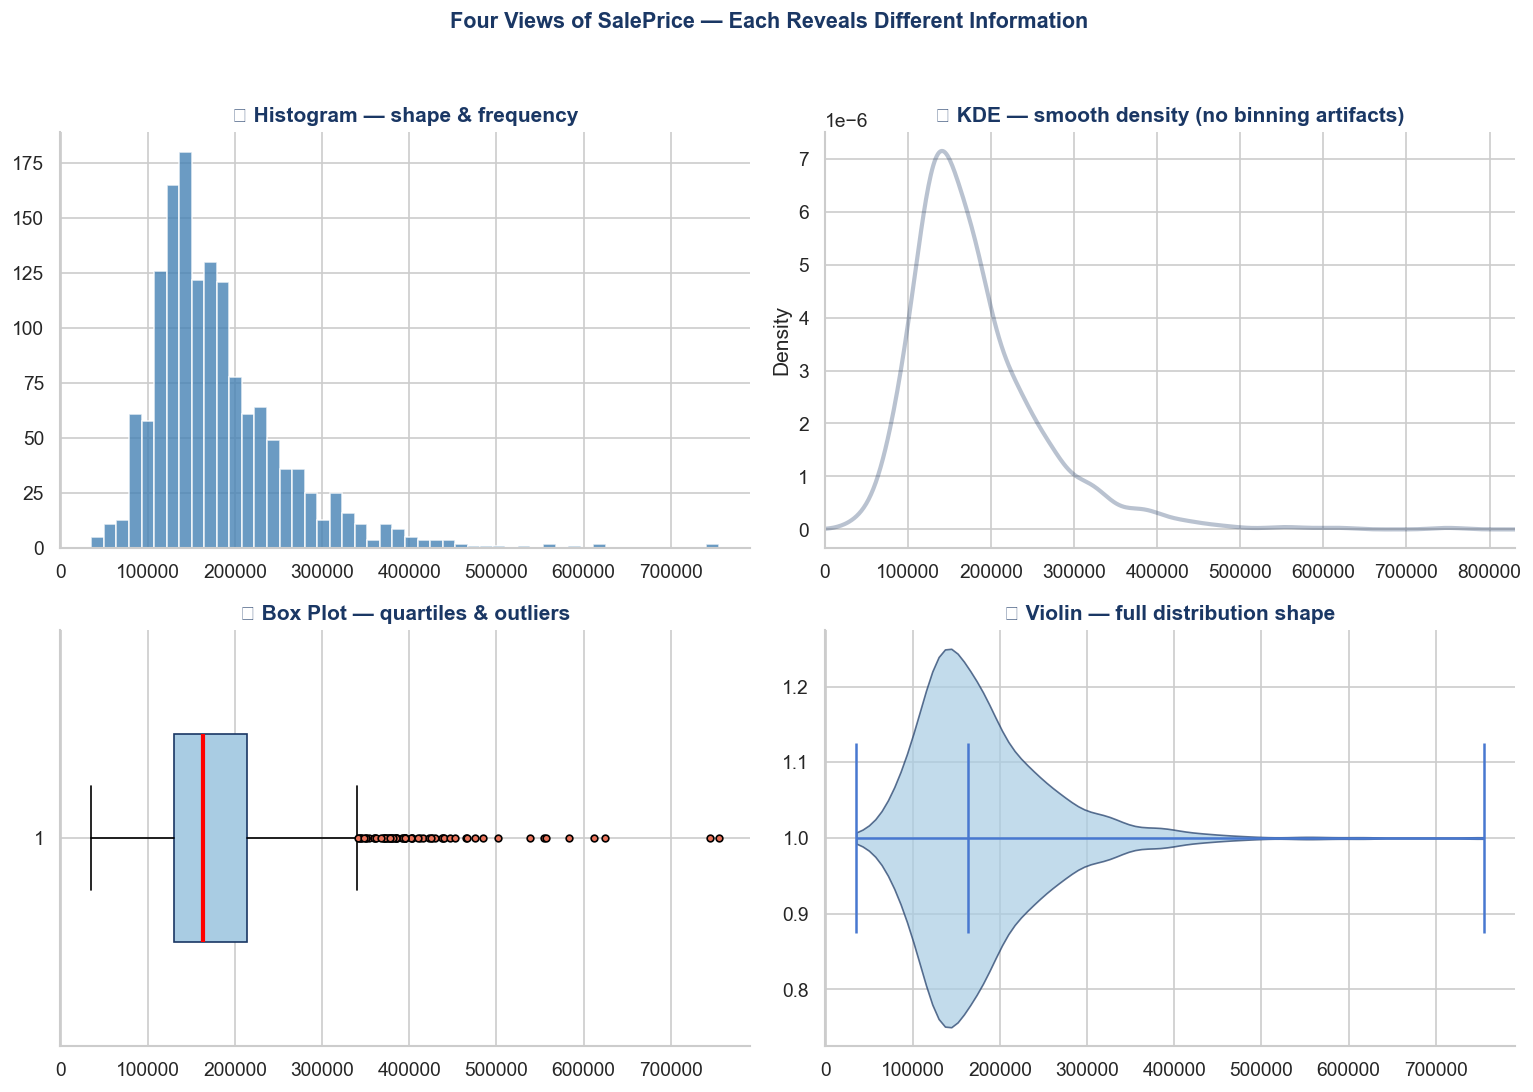

In [12]:
# 4a. Histogram + KDE + Box + Violin 
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Histogram
axes[0,0].hist(df['SalePrice'], bins=50, color=STEEL, alpha=0.8, edgecolor='white')
axes[0,0].set_title('① Histogram — shape & frequency', fontweight='bold', color=NAVY)

# KDE
df['SalePrice'].plot.kde(ax=axes[0,1], color=NAVY, lw=2.5, alpha=0.3)
axes[0,1].set_xlim(0, df['SalePrice'].max()*1.1)
axes[0,1].set_title('② KDE — smooth density (no binning artifacts)', fontweight='bold', color=NAVY)

# Box plot
axes[1,0].boxplot(df['SalePrice'], vert=False, patch_artist=True, widths=0.5,
 boxprops=dict(facecolor='#A9CCE3', edgecolor=NAVY),
 medianprops=dict(color='red', lw=2.5),
 flierprops=dict(marker='o', markerfacecolor=CORAL, markersize=4))
axes[1,0].set_title('③ Box Plot — quartiles & outliers', fontweight='bold', color=NAVY)

# Violin
parts = axes[1,1].violinplot(df['SalePrice'], vert=False, showmedians=True)
for body in parts['bodies']:
 body.set_facecolor('#A9CCE3'); body.set_edgecolor(NAVY); body.set_alpha(0.7)
axes[1,1].set_title('④ Violin — full distribution shape', fontweight='bold', color=NAVY)

for ax in axes.flatten(): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Four Views of SalePrice — Each Reveals Different Information', 
 fontweight='bold', color=NAVY, fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### 4.2 Bin Size Effect `[Slide 19]`

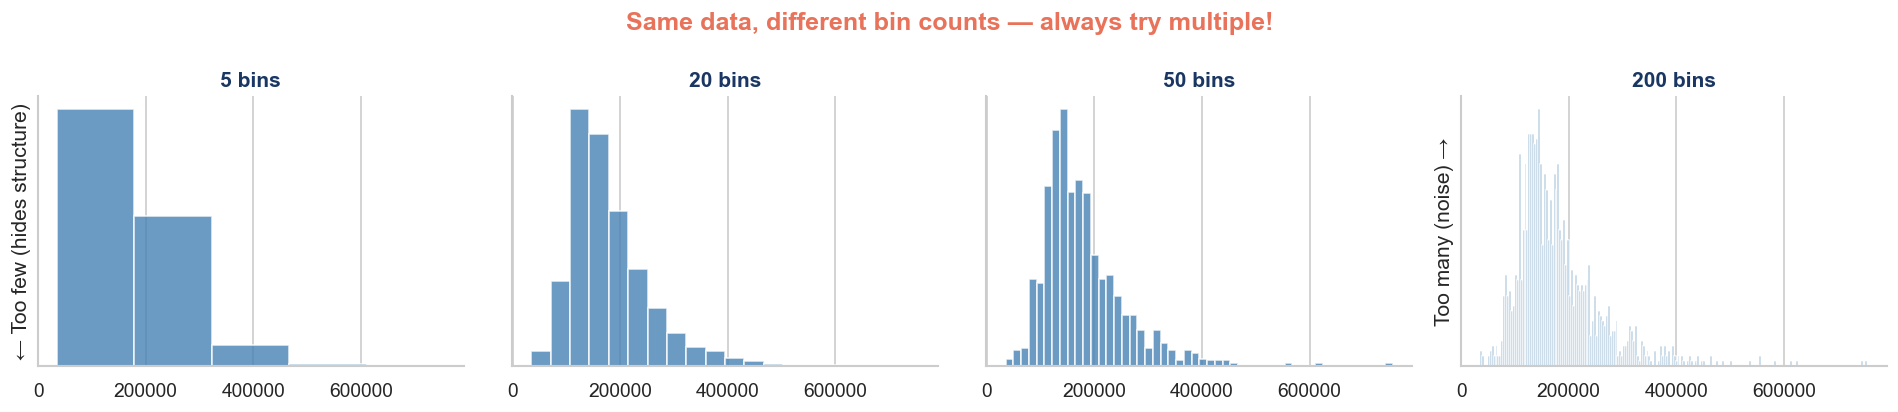

In [13]:
# 4b. Bin size matters! 
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, nb in zip(axes, [5, 20, 50, 200]):
 ax.hist(df['SalePrice'], bins=nb, color=STEEL, alpha=0.8, edgecolor='white')
 ax.set_title(f'{nb} bins', fontweight='bold', color=NAVY)
 ax.set_yticks([]); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[0].set_ylabel('← Too few (hides structure)')
axes[3].set_ylabel('Too many (noise) →')
plt.suptitle('Same data, different bin counts — always try multiple!', fontweight='bold', color=CORAL)
plt.tight_layout(); plt.show()

### 4.3 QQ-Plot: Testing Normality `[Slide 21]`

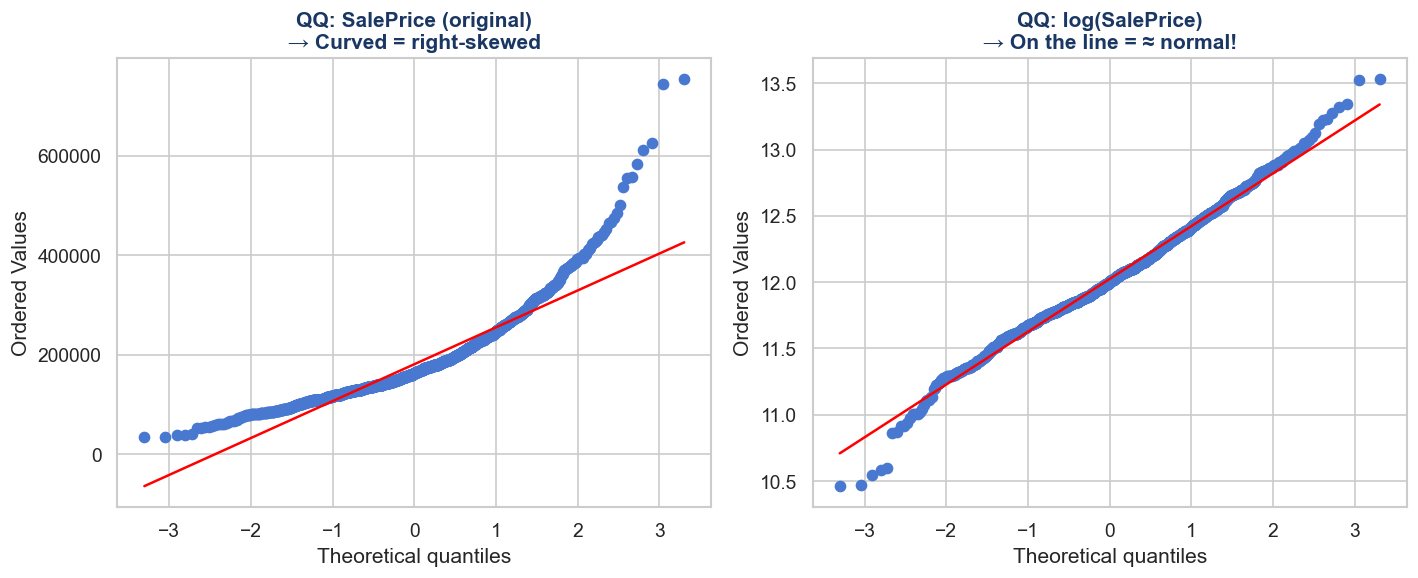

Shapiro-Wilk (n=500):
 Original: p = 4.70e-20 →  NOT normal
 Log: p = 1.28e-03 →  NOT normal


In [14]:
# 4c. QQ-plot: original vs log 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df['SalePrice'], plot=axes[0])
axes[0].set_title('QQ: SalePrice (original)\n→ Curved = right-skewed', fontweight='bold', color=NAVY)
axes[0].get_lines()[1].set_color('red')

stats.probplot(np.log1p(df['SalePrice']), plot=axes[1])
axes[1].set_title('QQ: log(SalePrice)\n→ On the line = ≈ normal!', fontweight='bold', color=NAVY)
axes[1].get_lines()[1].set_color('red')

plt.tight_layout(); plt.show()

# Shapiro-Wilk test (sample because n > 5000 → too sensitive)
sample = df['SalePrice'].sample(500, random_state=576)
_, p_orig = stats.shapiro(sample)
_, p_log = stats.shapiro(np.log1p(sample))
print(f'Shapiro-Wilk (n=500):')
print(f' Original: p = {p_orig:.2e} → {" Normal" if p_orig > 0.05 else " NOT normal"}')
print(f' Log: p = {p_log:.2e} → {" Normal" if p_log > 0.05 else " NOT normal"}')

### 4.4 Categorical Features `[Slide 22]`

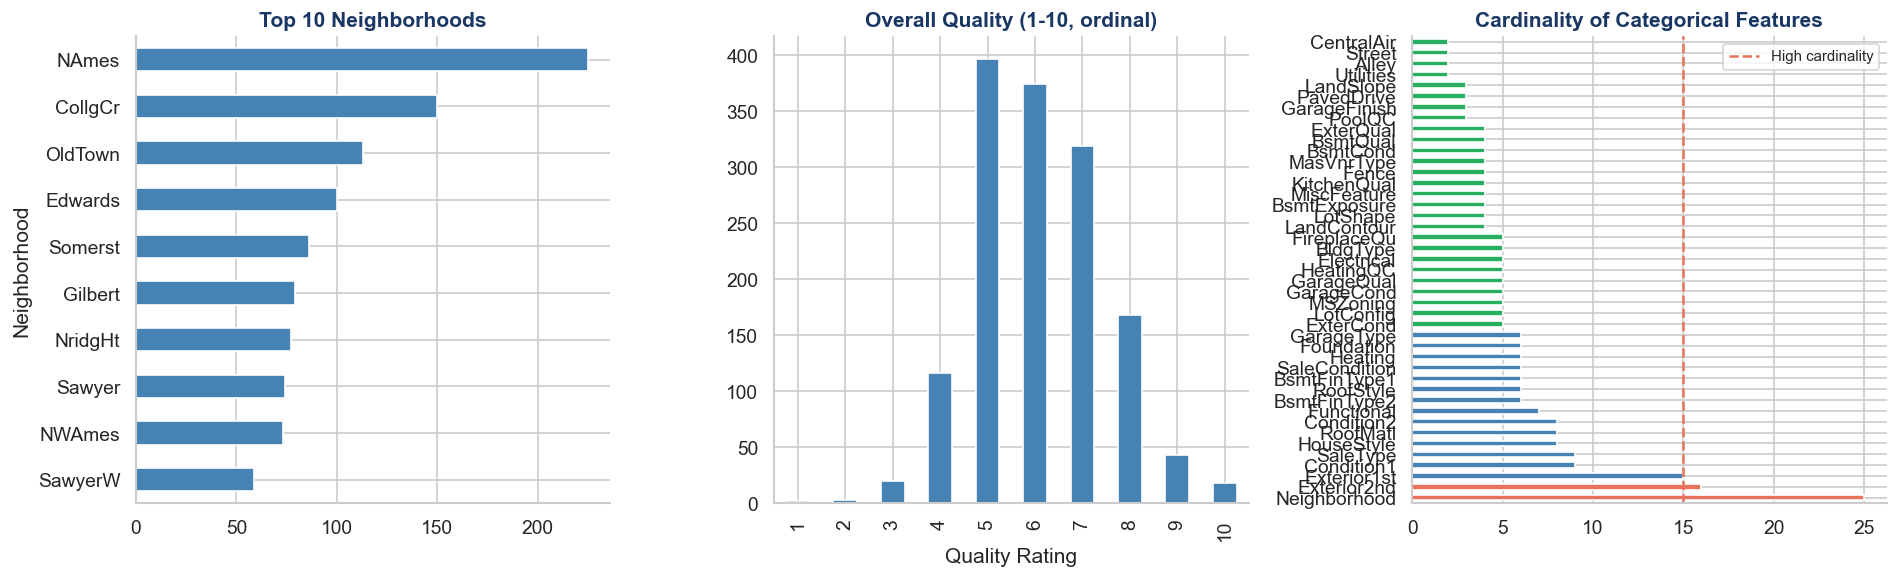

 HIGH-cardinality features (red) need target encoding or grouping [Slide 46]


In [15]:
# 4d. Categorical univariate 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
df['Neighborhood'].value_counts().head(10).plot.barh(ax=axes[0], color=STEEL, edgecolor='white')
axes[0].set_title('Top 10 Neighborhoods', fontweight='bold', color=NAVY)
axes[0].invert_yaxis()

# Overall quality (ordinal — order matters!)
df['OverallQual'].value_counts().sort_index().plot.bar(ax=axes[1], color=STEEL, edgecolor='white')
axes[1].set_title('Overall Quality (1-10, ordinal)', fontweight='bold', color=NAVY)
axes[1].set_xlabel('Quality Rating')

# Cardinality overview
card = df[cat_cols].nunique().sort_values(ascending=False)
colors_c = [CORAL if v > 15 else GREEN if v < 6 else STEEL for v in card]
card.plot.barh(ax=axes[2], color=colors_c, edgecolor='white')
axes[2].axvline(15, color=CORAL, ls='--', lw=1.5, label='High cardinality')
axes[2].legend(fontsize=9)
axes[2].set_title('Cardinality of Categorical Features', fontweight='bold', color=NAVY)

for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(' HIGH-cardinality features (red) need target encoding or grouping [Slide 46]')

---
## Step 5 — Bivariate Analysis `[Slides 24-29]` 15 min

Relationships between **pairs** of variables. This is where modeling insights emerge.

### 5.1 Numerical × Numerical: Scatter + Pearson `[Slide 24]`

In [16]:
# 5a. Top correlations with SalePrice 
corr_target = df[num_cols].corrwith(df['SalePrice']).drop('SalePrice', errors='ignore')
top_pos = corr_target.sort_values(ascending=False).head(8)
top_neg = corr_target.sort_values().head(3)

print('Strongest POSITIVE correlations with SalePrice:')
for feat, r in top_pos.items():
 bar = '' * int(abs(r) * 30)
 print(f' {feat:20s} r = {r:+.3f} {bar}')

print(f'\nStrongest NEGATIVE:')
for feat, r in top_neg.items():
 print(f' {feat:20s} r = {r:+.3f}')

Strongest POSITIVE correlations with SalePrice:
 OverallQual          r = +0.791 
 GrLivArea            r = +0.709 
 GarageCars           r = +0.640 
 GarageArea           r = +0.623 
 TotalBsmtSF          r = +0.614 
 1stFlrSF             r = +0.606 
 FullBath             r = +0.561 
 TotRmsAbvGrd         r = +0.534 

Strongest NEGATIVE:
 KitchenAbvGr         r = -0.136
 EnclosedPorch        r = -0.129
 MSSubClass           r = -0.084


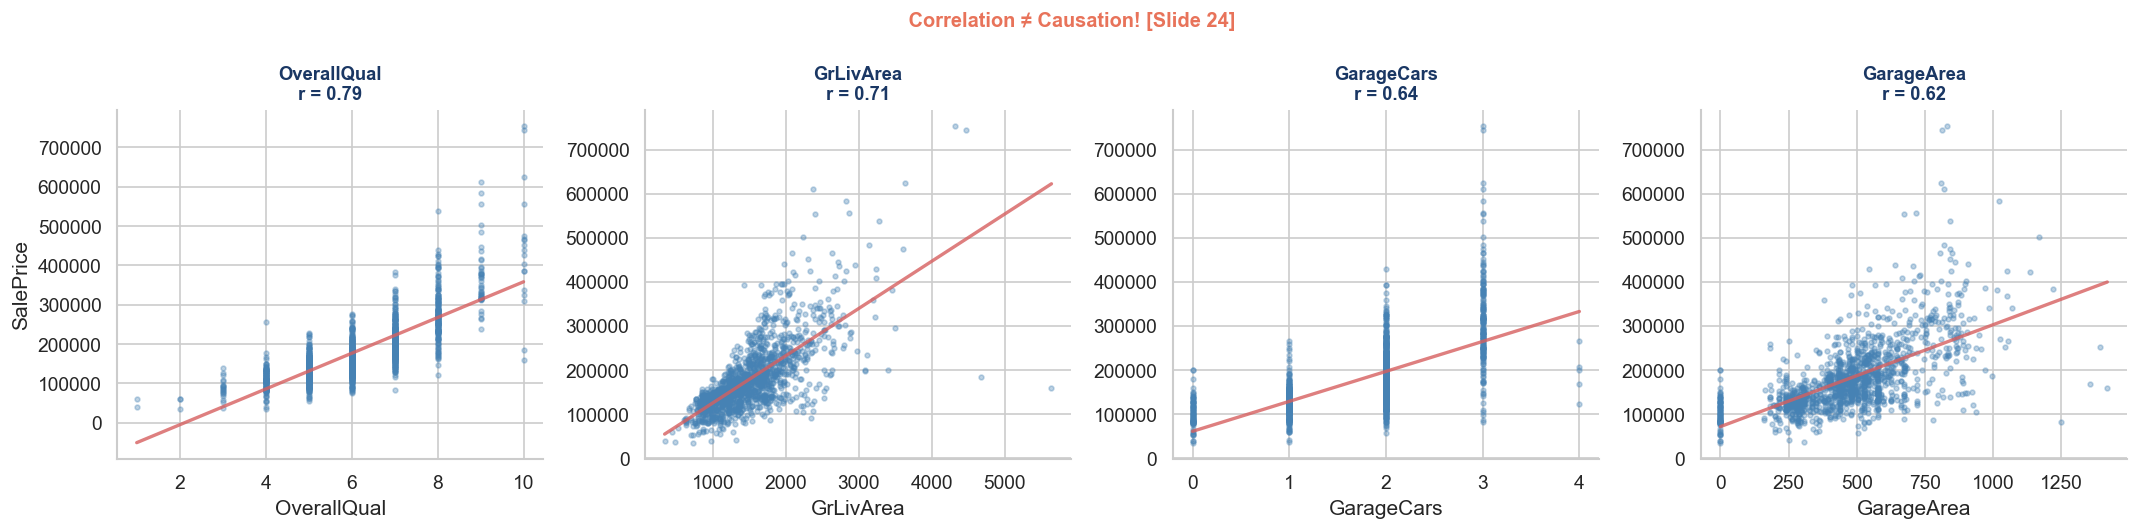

In [17]:
# 5b. Scatter plots of top 4 predictors 
top4 = top_pos.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, feat in zip(axes, top4):
 ax.scatter(df[feat], df['SalePrice'], s=8, alpha=0.35, color=STEEL)
 # Regression line
 mask = df[feat].notna()
 z = np.polyfit(df.loc[mask, feat], df.loc[mask, 'SalePrice'], 1)
 xl = np.linspace(df[feat].min(), df[feat].max(), 100)
 ax.plot(xl, np.polyval(z, xl), 'r-', lw=2, alpha=0.8)
 r = df[feat].corr(df['SalePrice'])
 ax.set_title(f'{feat}\nr = {r:.2f}', fontweight='bold', color=NAVY, fontsize=11)
 ax.set_xlabel(feat); ax.set_ylabel('SalePrice' if ax == axes[0] else '')
 ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle(' Correlation ≠ Causation! [Slide 24]', color=CORAL, fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

### 5.2 Correlation Heatmap + Spearman `[Slides 25-26]`

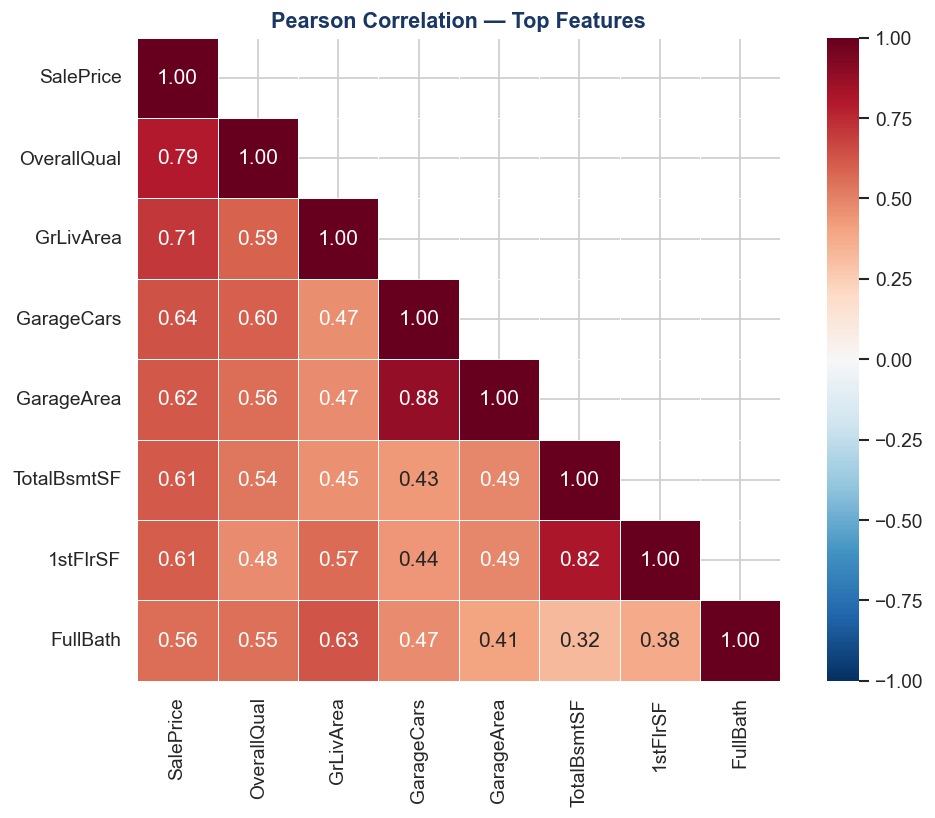

 Multicollinearity (r > 0.8 between features):
 GarageCars ↔ GarageArea: r = 0.88 → consider dropping one
 TotalBsmtSF ↔ 1stFlrSF: r = 0.82 → consider dropping one


In [21]:
# 5c. Correlation heatmap 
top8 = ['SalePrice'] + top_pos.head(7).index.tolist()
corr_matrix = df[top8].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
 vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation — Top Features', fontweight='bold', color=NAVY, fontsize=13)
plt.tight_layout(); plt.show()

# Multicollinearity check
print(' Multicollinearity (r > 0.8 between features):')
for i in range(1, len(top8)):
 for j in range(i+1, len(top8)):
  r = corr_matrix.iloc[i, j]
  if abs(r) > 0.8:
   print(f' {top8[i]} ↔ {top8[j]}: r = {r:.2f} → consider dropping one')

In [22]:
# 5d. Pearson vs Spearman comparison 
print(f'{"Feature":>20s} {"Pearson":>8s} {"Spearman":>9s} {"Δ":>5s}')
print('' * 50)
for feat in top8[1:]:
 r_p = df[feat].corr(df['SalePrice'], method='pearson')
 r_s = df[feat].corr(df['SalePrice'], method='spearman')
 d = abs(r_p - r_s)
 flag = ' ← non-linear!' if d > 0.05 else ''
 print(f'{feat:>20s} {r_p:>+8.3f} {r_s:>+9.3f} {d:>5.3f}{flag}')

print('\n→ When Pearson ≠ Spearman → relationship is non-linear [Slide 26]')

             Feature  Pearson  Spearman     Δ

         OverallQual   +0.791    +0.810 0.019
           GrLivArea   +0.709    +0.731 0.023
          GarageCars   +0.640    +0.691 0.050 ← non-linear!
          GarageArea   +0.623    +0.649 0.026
         TotalBsmtSF   +0.614    +0.603 0.011
            1stFlrSF   +0.606    +0.575 0.030
            FullBath   +0.561    +0.636 0.075 ← non-linear!

→ When Pearson ≠ Spearman → relationship is non-linear [Slide 26]


### 5.3 Categorical × Numerical: ANOVA `[Slides 27-28]`

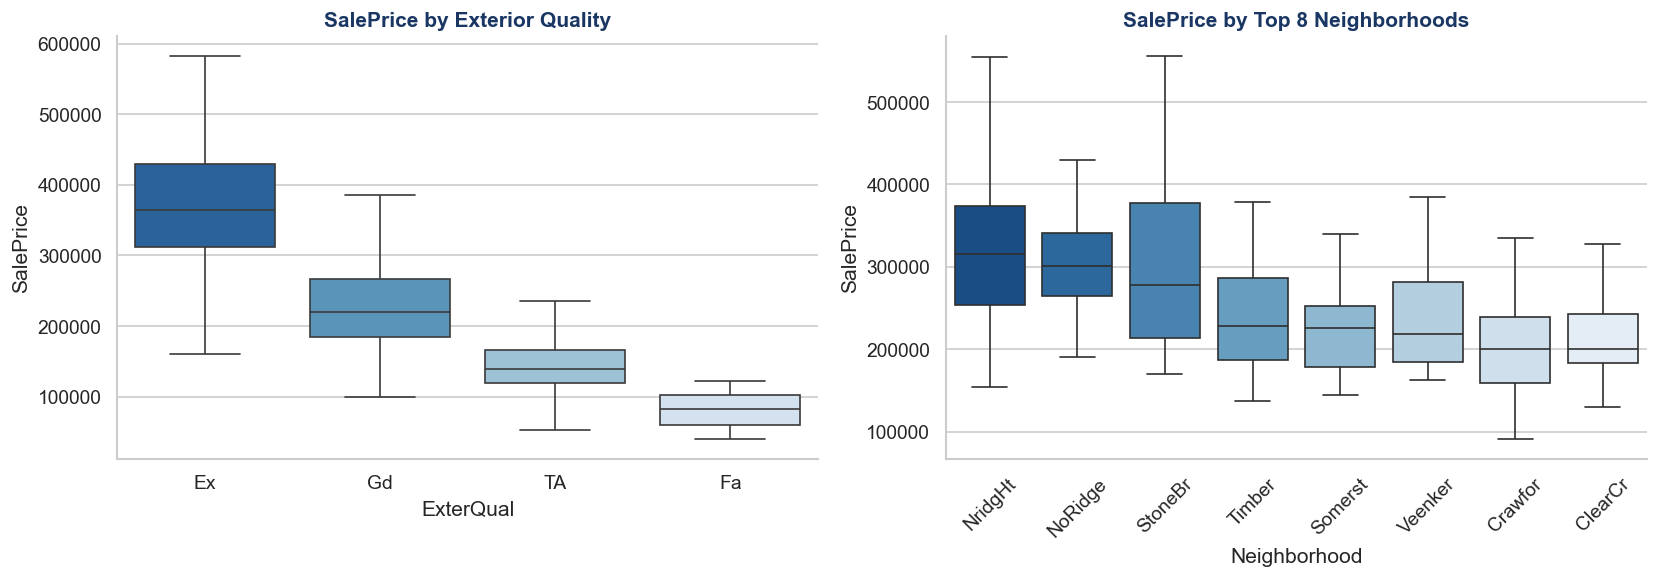

One-Way ANOVA (SalePrice ~ ExterQual): F = 443.3, p = 1.44e-204
→  Significant difference between quality groups


In [23]:
# 5e. Box plots by category + ANOVA 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ExterQual — ordinal
order_eq = [v for v in ['Ex', 'Gd', 'TA', 'Fa', 'Po'] if v in df['ExterQual'].unique()]
sns.boxplot(data=df, x='ExterQual', y='SalePrice', order=order_eq, ax=axes[0],
 palette='Blues_r', showfliers=False)
axes[0].set_title('SalePrice by Exterior Quality', fontweight='bold', color=NAVY)

# Neighborhood — top 8 by median price
top_neigh = df.groupby('Neighborhood')['SalePrice'].median().nlargest(8).index
sns.boxplot(data=df[df['Neighborhood'].isin(top_neigh)], x='Neighborhood', y='SalePrice',
 order=top_neigh, ax=axes[1], palette='Blues_r', showfliers=False)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('SalePrice by Top 8 Neighborhoods', fontweight='bold', color=NAVY)

for ax in axes: ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# ANOVA
groups = [g['SalePrice'].dropna() for _, g in df.groupby('ExterQual')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'One-Way ANOVA (SalePrice ~ ExterQual): F = {f_stat:.1f}, p = {p_val:.2e}')
print(f'→ {" Significant" if p_val < 0.05 else " Not significant"} difference between quality groups')

### 5.4 Categorical × Categorical: Chi² `[Slide 29]`

Contingency Table (MSZoning × BldgType):
BldgType   1Fam  2fmCon  Duplex  Twnhs  TwnhsE
MSZoning                                      
'C (all)'     9       1       0      0       0
FV           38       0       0      9      18
RH            9       2       3      0       2
RL         1025      16      43     10      57
RM          139      12       6     24      37

χ² = 223.0, dof = 16, p = 1.75e-38
→  NOT independent (p < 0.05)


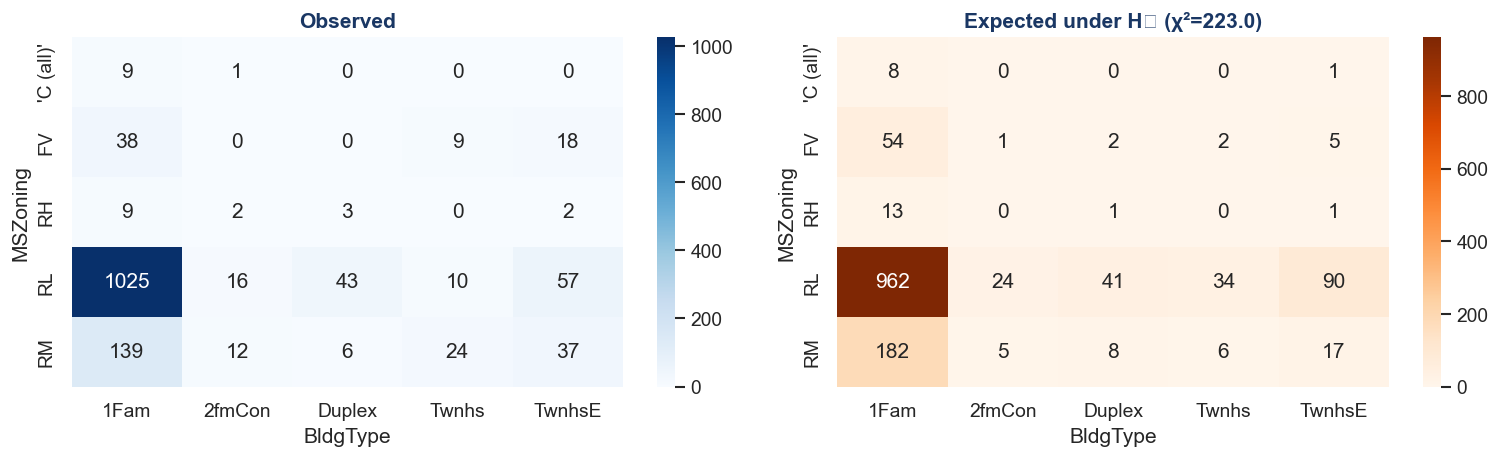

In [24]:
# 5f. Contingency table + chi-squared 
ct = pd.crosstab(df['MSZoning'], df['BldgType'])
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f'Contingency Table (MSZoning × BldgType):')
print(ct.to_string())
print(f'\nχ² = {chi2:.1f}, dof = {dof}, p = {p:.2e}')
print(f'→ {" NOT independent" if p < 0.05 else " Independent"} (p {"<" if p < 0.05 else ">"} 0.05)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Observed', fontweight='bold', color=NAVY)
sns.heatmap(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(0).astype(int),
 annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Expected under H₀ (χ²={chi2:.1f})', fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show()

---
## Step 6 — Multivariate Analysis `[Slides 31-33]` 8 min

### 6.1 Pair Plot `[Slide 31]`

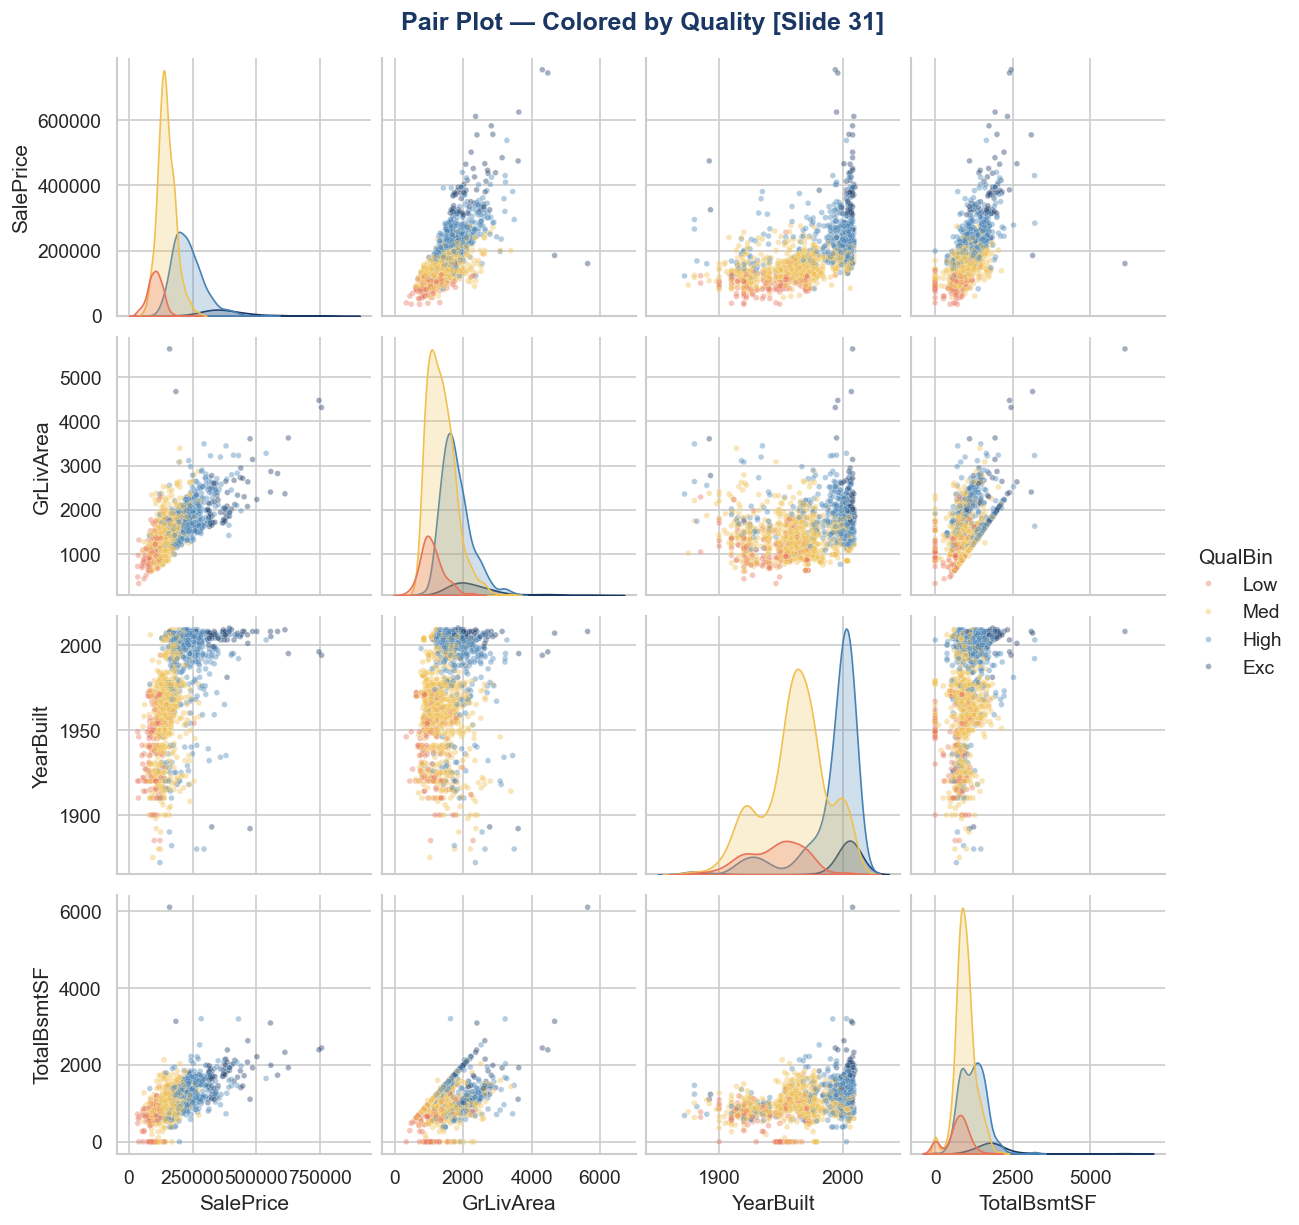

→ Limit to 5-7 features max; panels become unreadable beyond that


In [25]:
# 6a. Pair plot with quality hue 
pair_feats = ['SalePrice', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF']
df['QualBin'] = pd.cut(df['OverallQual'], bins=[0,4,6,8,10], labels=['Low','Med','High','Exc'])

g = sns.pairplot(df[pair_feats + ['QualBin']].dropna(), hue='QualBin',
 palette={'Low': CORAL, 'Med': '#F0C050', 'High': STEEL, 'Exc': NAVY},
 plot_kws={'s': 12, 'alpha': 0.4}, diag_kind='kde', height=2.5)
g.fig.suptitle('Pair Plot — Colored by Quality [Slide 31]', fontweight='bold', color=NAVY, y=1.02)
plt.show()

print('→ Limit to 5-7 features max; panels become unreadable beyond that')

### 6.2 PCA `[Slides 32-33]`

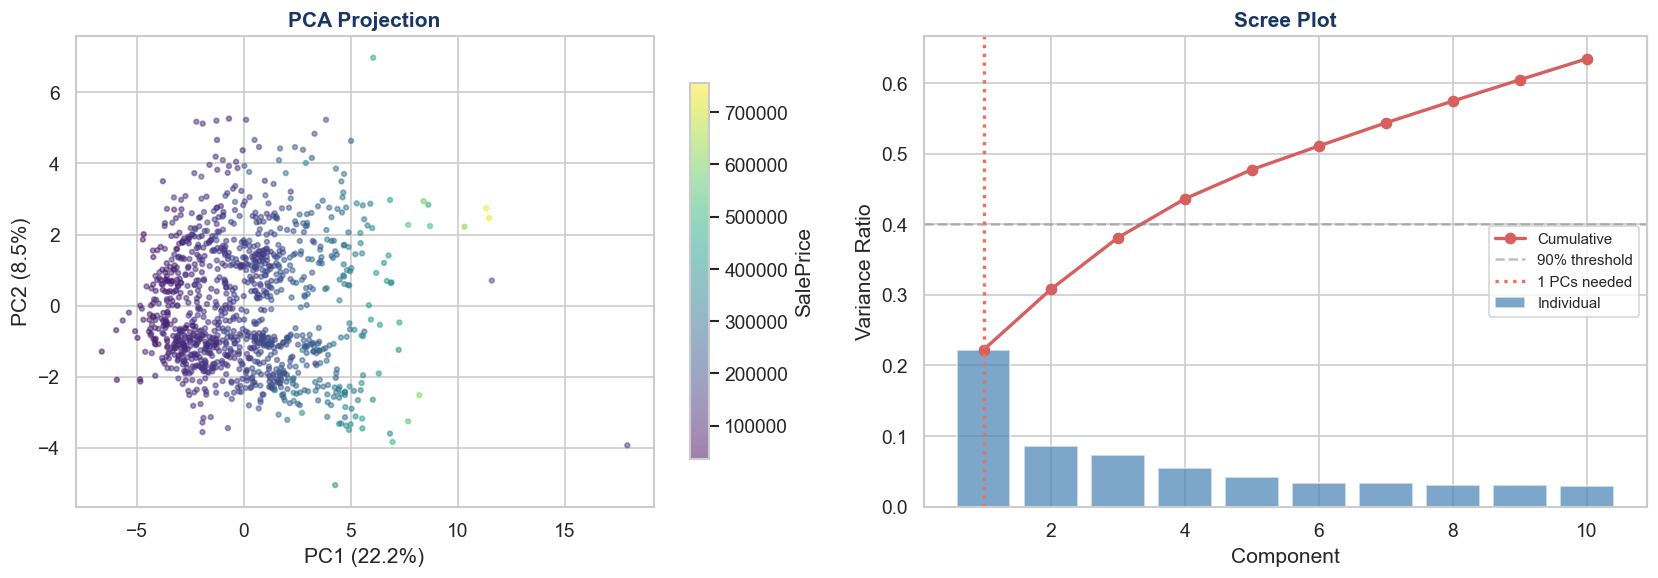

→ 1 components capture 22% of variance from 37 features


In [28]:
# 6b. PCA projection + scree plot 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[num_cols].dropna()
idx = X.index
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Projection
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df.loc[idx, 'SalePrice'],
 cmap='viridis', s=8, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label='SalePrice', shrink=0.8)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA Projection', fontweight='bold', color=NAVY)

# Scree
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].bar(range(1,11), pca.explained_variance_ratio_, color=STEEL, alpha=0.7, label='Individual')
axes[1].plot(range(1,11), cumvar, 'ro-', lw=2, label='Cumulative')
axes[1].axhline(0.4, color='gray', ls='--', alpha=0.5, label='90% threshold')
n90 = np.argmax(cumvar >= 0.9) + 1
axes[1].axvline(n90, color=CORAL, ls=':', lw=2, label=f'{n90} PCs needed')
axes[1].legend(fontsize=9); axes[1].set_xlabel('Component'); axes[1].set_ylabel('Variance Ratio')
axes[1].set_title('Scree Plot', fontweight='bold', color=NAVY)

plt.tight_layout(); plt.show()
print(f'→ {n90} components capture 22% of variance from {len(num_cols)} features')

---
## Step 7 — Missing Data `[Slides 36-38]` 10 min

> **The pattern of missingness contains information!** — See Rubin's taxonomy `[Slide 36]`

| Type | Mechanism | Strategy |
|------|-----------|----------|
| **MCAR** | Independent of all data | Drop rows |
| **MAR** | Depends on *observed* data | Impute |
| **MNAR** | Depends on *missing value itself* | Domain knowledge |

In [ ]:
# 7a. Missing data overview 
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0]

print(f'Features with missing values: {len(missing_df)} / {df.shape[1]}')
print(f'Features > 50% missing: {(missing_pct > 50).sum()}')
print(f'Features > 80% missing: {(missing_pct > 80).sum()}')
print(f'\nTop 10 missing:')
for feat, pct in missing_df.head(10).items():
 bar = '' * int(pct / 2)
 print(f' {feat:18s} {pct:5.1f}% {bar}')

In [ ]:
# 7b. Missing data visualization [Slide 37] 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
top_miss = missing_df.head(12)
colors_m = [CORAL if v > 50 else '#E67E22' if v > 20 else GREEN for v in top_miss]
top_miss.plot.barh(ax=axes[0], color=colors_m, edgecolor='white')
axes[0].axvline(50, color='red', ls='--', lw=1.5, alpha=0.7, label='50% threshold')
axes[0].set_xlabel('% Missing'); axes[0].set_title('Missing %', fontweight='bold', color=NAVY)
axes[0].legend(fontsize=9); axes[0].invert_yaxis()

# Pattern matrix
miss_feats = missing_df.head(10).index.tolist()
sns.heatmap(df[miss_feats].isnull().astype(int).head(150).T, cmap=['#F7DC6F', '#922B21'],
 cbar=False, ax=axes[1], yticklabels=True)
axes[1].set_title('Missingness Pattern (first 150 rows)', fontweight='bold', color=NAVY)
axes[1].set_xlabel('Row index')
plt.tight_layout(); plt.show()

print('→ PoolQC ≈ 99.5% missing = most houses have NO pool (not truly "missing")')
print('→ Garage features missing TOGETHER → houses with no garage')

In [ ]:
# 7c. Imputation: Mean vs KNN [Slide 38] 
from sklearn.impute import KNNImputer

feat = 'LotFrontage'
observed = df[feat].dropna()
n_miss = df[feat].isnull().sum()
print(f'{feat}: {n_miss} missing ({n_miss/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean
axes[0].hist(observed, bins=30, alpha=0.5, color='gray', edgecolor='white', label='Observed')
m = observed.mean()
axes[0].axvline(m, color=STEEL, lw=3, ls='--')
axes[0].bar(m, n_miss, width=3, color=STEEL, alpha=0.9, label=f'Imputed (n={n_miss})')
axes[0].set_title('Mean Imputation', fontweight='bold', color=NAVY)
axes[0].legend(fontsize=8)
axes[0].annotate('Spike!', xy=(m+2, n_miss*0.9), color=CORAL, fontweight='bold')

# Median
axes[1].hist(observed, bins=30, alpha=0.5, color='gray', edgecolor='white', label='Observed')
med = observed.median()
axes[1].axvline(med, color='#E67E22', lw=3, ls='--')
axes[1].bar(med, n_miss, width=3, color='#E67E22', alpha=0.9, label=f'Imputed (n={n_miss})')
axes[1].set_title('Median Imputation', fontweight='bold', color=NAVY)
axes[1].legend(fontsize=8)
axes[1].annotate('Same spike!', xy=(med+2, n_miss*0.9), color=CORAL, fontweight='bold')

# KNN
knn = KNNImputer(n_neighbors=5)
knn_vals = knn.fit_transform(df[['LotFrontage', 'LotArea', 'GrLivArea']].select_dtypes(np.number))
knn_imputed = knn_vals[df[feat].isnull(), 0]
axes[2].hist(observed, bins=30, alpha=0.5, color='gray', edgecolor='white', label='Observed')
axes[2].hist(knn_imputed, bins=20, alpha=0.7, color=GREEN, edgecolor='white', label=f'KNN (n={n_miss})')
axes[2].set_title('KNN Imputation', fontweight='bold', color=NAVY)
axes[2].legend(fontsize=8)
axes[2].annotate('Follows distribution!', xy=(45, 12), color=GREEN, fontweight='bold')

for ax in axes: ax.set_yticks([]); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('Mean/Median → artificial spike | KNN → preserves shape [Slide 38]', color=CORAL, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 8 — Outlier Detection `[Slides 40-42]` 8 min

### 8.1 IQR Method & Z-Score `[Slide 40]`

In [ ]:
# 8a. IQR vs Z-score 
def outliers_iqr(s, k=1.5):
 q1, q3 = s.quantile([0.25, 0.75])
 iqr = q3 - q1
 return (s < q1 - k*iqr) | (s > q3 + k*iqr), q1 - k*iqr, q3 + k*iqr

def outliers_z(s, thresh=3):
 z = np.abs(stats.zscore(s.dropna()))
 mask = pd.Series(False, index=s.index)
 mask.loc[s.dropna().index] = z > thresh
 return mask

feat = 'GrLivArea'
iqr_mask, lo, hi = outliers_iqr(df[feat].dropna())
z_mask = outliers_z(df[feat])

print(f'Outliers in {feat}:')
print(f' IQR (1.5×): {iqr_mask.sum()} outliers (bounds: [{lo:.0f}, {hi:.0f}])')
print(f' Z-score (|z|>3): {z_mask.sum()} outliers')

# Scatter: GrLivArea vs SalePrice with outliers highlighted
fig, ax = plt.subplots(figsize=(10, 6))
clean_mask = ~iqr_mask
ax.scatter(df.loc[clean_mask, 'GrLivArea'], df.loc[clean_mask, 'SalePrice'], s=10, alpha=0.4, color=STEEL, label='Normal')
ax.scatter(df.loc[iqr_mask, 'GrLivArea'], df.loc[iqr_mask, 'SalePrice'], s=40, color=CORAL, marker='X', label=f'IQR Outliers ({iqr_mask.sum()})')
ax.axvline(hi, color=CORAL, ls='--', lw=1.5, alpha=0.5, label=f'Upper fence = {hi:.0f}')
ax.set_xlabel('GrLivArea (sq ft)'); ax.set_ylabel('SalePrice ($)')
ax.set_title('Outlier Detection: IQR Method [Slide 40]', fontweight='bold', color=NAVY)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 8.2 Isolation Forest `[Slide 41]`

In [ ]:
# 8b. Isolation Forest (multivariate) 
from sklearn.ensemble import IsolationForest

X_iso = df[['GrLivArea', 'SalePrice']].dropna()
iso = IsolationForest(contamination=0.02, random_state=42)
labels = iso.fit_predict(X_iso)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_iso.loc[labels==1, 'GrLivArea'], X_iso.loc[labels==1, 'SalePrice'],
 s=10, alpha=0.4, color=STEEL, label='Normal')
ax.scatter(X_iso.loc[labels==-1, 'GrLivArea'], X_iso.loc[labels==-1, 'SalePrice'],
 s=40, color=CORAL, marker='X', label=f'Outliers ({(labels==-1).sum()})')
ax.set_xlabel('GrLivArea'); ax.set_ylabel('SalePrice')
ax.set_title('Isolation Forest — Multivariate Outliers [Slide 41]', fontweight='bold', color=NAVY)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# Decision framework [Slide 42]
print('\n Outlier Decision Framework [Slide 42]:')
print(' 1. Data error (typo, sensor) → REMOVE')
print(' 2. Valid extreme → CAP / WINSORIZE')
print(' 3. Skewed distribution → LOG TRANSFORM')
print(' 4. Informative (fraud, rare) → KEEP + robust methods')
print(' 5. Always: compare model with/without outlier treatment!')

---
## Step 9 — Data Transformations `[Slides 44-46]` 8 min

### 9.1 Log Transform `[Slide 44]`

In [ ]:
# 9a. Log transform on skewed features 
skewed_feats = shape_stats[shape_stats['Skewness'].abs() > 1].index.tolist()
# Pick 3 examples
examples = ['SalePrice', 'LotArea', 'GrLivArea']

fig, axes = plt.subplots(len(examples), 2, figsize=(13, 3.5*len(examples)))
for i, feat in enumerate(examples):
 data = df[feat].dropna()
 data_log = np.log1p(data)
 
 axes[i,0].hist(data, bins=50, color=STEEL, alpha=0.8, edgecolor='white')
 axes[i,0].set_title(f'{feat} — skew = {data.skew():.2f}', fontweight='bold', color=NAVY)
 
 axes[i,1].hist(data_log, bins=50, color='#E67E22', alpha=0.8, edgecolor='white')
 axes[i,1].set_title(f'log({feat}) — skew = {data_log.skew():.2f}', fontweight='bold', color=NAVY)
 
 for ax in axes[i]: ax.set_yticks([]); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[0,0].set_ylabel('ORIGINAL', fontsize=12, fontweight='bold', color=NAVY)
axes[0,1].set_ylabel('LOG TRANSFORMED', fontsize=12, fontweight='bold', color='#E67E22')
plt.suptitle(f'Log Transform: x\' = log(x + 1) — {len(skewed_feats)} features with |skew| > 1 [Slide 44]',
 fontweight='bold', color=NAVY, fontsize=13)
plt.tight_layout(); plt.show()

### 9.2 Feature Scaling `[Slide 45]`

In [ ]:
# 9b. Scaling comparison 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

raw = df['GrLivArea'].dropna().values.reshape(-1, 1)

scalers = {
 'Original': raw.flatten(),
 'StandardScaler\n(μ=0, σ=1)': StandardScaler().fit_transform(raw).flatten(),
 'MinMaxScaler\n([0, 1])': MinMaxScaler().fit_transform(raw).flatten(),
 'RobustScaler\n(median/IQR)': RobustScaler().fit_transform(raw).flatten(),
 'Yeo-Johnson\n(Gaussianize)': PowerTransformer(method='yeo-johnson').fit_transform(raw).flatten(),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
colors = [STEEL, '#2E86C1', GREEN, '#E67E22', '#8E44AD']
for ax, (name, vals), c in zip(axes, scalers.items(), colors):
 ax.hist(vals, bins=40, color=c, alpha=0.8, edgecolor='white')
 ax.set_title(name, fontweight='bold', color=NAVY, fontsize=10)
 ax.set_yticks([]); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('Same data, different scales [Slide 45]', fontweight='bold', color=NAVY, fontsize=12)
plt.tight_layout(); plt.show()

print('StandardScaler: default. MinMaxScaler: neural nets. RobustScaler: outliers. Yeo-Johnson: Gaussianize.')

### 9.3 Encoding `[Slide 46]`

In [ ]:
# 9c. Three encoding strategies 

# 1. Label encoding (ordinal)
label_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
df['ExterQual_enc'] = df['ExterQual'].map(label_map)
print('1. LABEL ENCODING (ordinal): ExterQual → numeric')
print(df[['ExterQual','ExterQual_enc']].drop_duplicates().dropna().sort_values('ExterQual_enc', ascending=False).to_string(index=False))

# 2. One-hot encoding (nominal)
ohe = pd.get_dummies(df['BldgType'], prefix='Bldg')
print(f'\n2. ONE-HOT ENCODING (nominal): BldgType → {ohe.shape[1]} binary columns')
print(ohe.head(3).to_string())

# 3. Target encoding (high cardinality)
target_enc = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
print(f'\n3. TARGET ENCODING (high cardinality): Neighborhood → mean SalePrice')
print(target_enc.head(5).apply(lambda x: f'${x:,.0f}').to_string())
print(' Always use cross-validated target encoding to avoid leakage!')

---
## Step 10 — Wrap-up `[Slides 48-53]` 2 min

### Anscombe's Quartet — Why We ALWAYS Visualize `[Slide 48]`

In [ ]:
# Anscombe's Quartet 
anscombe = sns.load_dataset('anscombe')

print('Four datasets with IDENTICAL statistics:')
for ds in ['I', 'II', 'III', 'IV']:
 d = anscombe[anscombe['dataset'] == ds]
 print(f' Dataset {ds}: mean(x)={d["x"].mean():.1f}, mean(y)={d["y"].mean():.2f}, '
 f'r={d["x"].corr(d["y"]):.3f}')

g = sns.lmplot(data=anscombe, x='x', y='y', col='dataset', col_wrap=2,
 height=3, aspect=1.3, scatter_kws={'s': 40, 'color': STEEL},
 line_kws={'color': 'red', 'lw': 2})
g.fig.suptitle('Same Statistics → Completely Different Patterns!', fontweight='bold', color=CORAL, fontsize=14, y=1.02)
plt.show()
print('\n LESSON: Never skip visualization. Statistics can lie. [Slide 48]')

### EDA Checklist — Before You Model `[Slide 53]`

Run through this checklist before starting any modeling:

- [ ] Shape, types, and column names understood?
- [ ] Missing value patterns identified and strategy decided?
- [ ] Every feature's distribution examined?
- [ ] Outliers detected and handling strategy chosen?
- [ ] Feature-target correlations verified?
- [ ] Multicollinearity addressed?
- [ ] Transformations applied (log, scaling)?
- [ ] Categorical features encoded?
- [ ] All findings documented?

> **Only when all boxes are checked → proceed to modeling.**

---

### Summary of what we did today

| Step | What | Key Finding (Ames) |
|------|------|--------------------|
| 1 | First contact | 1,460 × 81, no duplicates |
| 2 | Data types | 38 numerical, 43 categorical |
| 3 | Summary stats | SalePrice right-skewed (skew ≈ 1.9) |
| 4 | Univariate | Many features highly skewed; QQ confirms non-normality |
| 5 | Bivariate | OverallQual (r=0.79) and GrLivArea (r=0.71) top predictors |
| 6 | Multivariate | 6 PCs capture 90% variance; quality separates clusters |
| 7 | Missing data | 19 features missing; PoolQC = 99.5% (no pool, not error) |
| 8 | Outliers | 2 extreme GrLivArea points; Isolation Forest detects multivariate |
| 9 | Transforms | Log reduces skew from 1.9 → 0.1; RobustScaler for outliers |

---
*End of Hands-On Lab — LUISS Guido Carli*